In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')   # unnecessary warnings hide karne ke liye

In [26]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')

In [27]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


In [28]:
df.isnull()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,False,False,False,False,False,False,False,False,False,False,False,False,False
295,False,False,False,False,False,False,False,False,False,False,False,False,False
296,False,False,False,False,False,False,False,False,False,False,False,False,False
297,False,False,False,False,False,False,False,False,False,False,False,False,False


In [29]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [30]:
df.columns.value_counts()

age                         1
anaemia                     1
creatinine_phosphokinase    1
diabetes                    1
ejection_fraction           1
high_blood_pressure         1
platelets                   1
serum_creatinine            1
serum_sodium                1
sex                         1
smoking                     1
time                        1
DEATH_EVENT                 1
Name: count, dtype: int64

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [32]:
df['age'] = df['age'].astype(int)

In [33]:

df.age.value_counts()

age
60    35
50    27
65    26
70    25
45    19
55    17
75    11
53    10
58    10
63     8
72     7
80     7
42     7
40     7
85     6
62     5
52     5
68     5
49     4
61     4
51     4
73     4
59     4
69     3
82     3
90     3
64     3
46     3
78     2
48     2
57     2
54     2
77     2
67     2
95     2
44     2
66     2
87     1
79     1
41     1
94     1
86     1
81     1
43     1
47     1
56     1
Name: count, dtype: int64

In [34]:
 x = df.drop('DEATH_EVENT',axis=1)
y= df.DEATH_EVENT

In [35]:
x.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time'],
      dtype='object')

In [36]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.20, random_state=42)

In [37]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [38]:
Model = LogisticRegression()

In [39]:
Model.fit(x,y)

LogisticRegression()

In [45]:
y_predic = Model.predict(x_test_scaled)
y_predic_prob = Model.predict_proba(x_test_scaled)
print (y_predic)


[1 0 0 1 0 0 1 0 1 1 0 1 1 1 1 1 0 1 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0
 1 1 0 1 1 0 0 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1]


In [46]:
print (y_predic_prob)

[[0.49896055 0.50103945]
 [0.51282263 0.48717737]
 [0.50336341 0.49663659]
 [0.45626682 0.54373318]
 [0.51751787 0.48248213]
 [0.50738624 0.49261376]
 [0.47809005 0.52190995]
 [0.50684984 0.49315016]
 [0.46533188 0.53466812]
 [0.48479339 0.51520661]
 [0.52066798 0.47933202]
 [0.49172373 0.50827627]
 [0.48584886 0.51415114]
 [0.49114749 0.50885251]
 [0.49936863 0.50063137]
 [0.49140801 0.50859199]
 [0.52860874 0.47139126]
 [0.496951   0.503049  ]
 [0.50419339 0.49580661]
 [0.47980463 0.52019537]
 [0.47809452 0.52190548]
 [0.51133627 0.48866373]
 [0.4812654  0.5187346 ]
 [0.48840613 0.51159387]
 [0.4936257  0.5063743 ]
 [0.52425823 0.47574177]
 [0.50065486 0.49934514]
 [0.53226677 0.46773323]
 [0.50747536 0.49252464]
 [0.50310774 0.49689226]
 [0.4782245  0.5217755 ]
 [0.52163898 0.47836102]
 [0.49191221 0.50808779]
 [0.4662385  0.5337615 ]
 [0.50492905 0.49507095]
 [0.52881939 0.47118061]
 [0.52020409 0.47979591]
 [0.49286835 0.50713165]
 [0.49995584 0.50004416]
 [0.54927387 0.45072613]


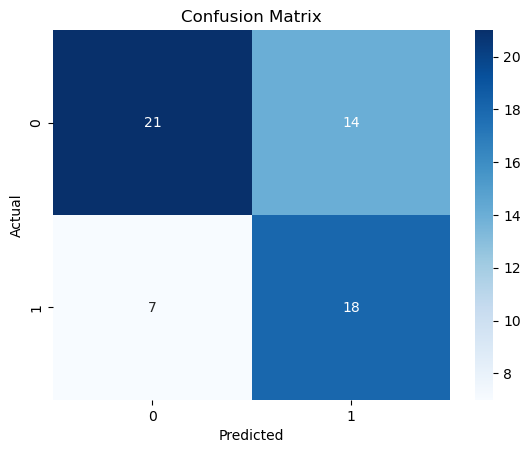

In [51]:
cm = confusion_matrix(y_test, y_predic)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [53]:
print(classification_report(y_test, y_predic))

              precision    recall  f1-score   support

           0       0.75      0.60      0.67        35
           1       0.56      0.72      0.63        25

    accuracy                           0.65        60
   macro avg       0.66      0.66      0.65        60
weighted avg       0.67      0.65      0.65        60



In [59]:
accuracy  = accuracy_score(y_test, y_predic)
precision = precision_score(y_test, y_predic)
recall    = recall_score(y_test, y_predic)
f1        = f1_score(y_test, y_predic)
roc_auc   = roc_auc_score(y_test, y_predic_prob)

print(f"Accuracy : {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")

ValueError: y should be a 1d array, got an array of shape (60, 2) instead.